#  DST-Based *BRCA1/2* Risk Estimation from Synthetic Data

In this notebook, we demonstrate how to estimate the likelihood of cancer patients carrying a pathogenic *BRCA1/2* variants, using a combined set-based Dempster-Shafer approach, based on a synthetic data set.

In [1]:
using UncertainEvidence
using IntervalArithmetic
using ThickIntervals
using CSV
using DataFrames
using Plots
using PGFPlotsX
using PrettyTables

In [2]:
setdisplay(:infsup; decorations = false, ng_flag = false, sigdigits = 2);

In [3]:
function print_comparison_table(curve_val, prev_val, penn_val, boadicea_val)
    pretty_table(
        [curve_val prev_val penn_val boadicea_val];
        column_labels=["This approach", "Prev. approach", "Penn II", "BOADICEA"],
        backend=:html
    )
end;

---

## Source data

In [4]:
min_age = 16;
max_age = 85;
df = CSV.read("frequencies.csv", DataFrame);
df[:, "age.interval"] = interval.(vcat(min_age, collect(21:5:81)), vcat(collect(20:5:80), max_age));
reverse!(df)

Row,age.group,fbc.positive,fbc.total,bbc.positive,bbc.total,tnbc.positive,tnbc.total,mbc.positive,mbc.total,oc.positive,oc.total,sp.positive,sp.total,age.interval
,String7,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Interval…
1,>80,19,28433,2,6202,8,4327,6,344,2,2893,245,3382,"[81.0, 85.0]"
2,76-80,64,33281,12,7228,22,4995,8,441,9,3409,246,3421,"[76.0, 80.0]"
3,71-75,175,36197,29,7889,61,5394,11,448,20,3862,280,3417,"[71.0, 75.0]"
4,66-70,433,39037,90,8605,149,5943,53,567,74,4075,361,3314,"[66.0, 70.0]"
5,61-65,923,40168,211,8945,341,6234,33,557,185,4165,358,2971,"[61.0, 65.0]"
6,56-60,1561,40485,333,9045,526,6413,29,500,298,4480,432,2639,"[56.0, 60.0]"
7,51-55,2364,39501,544,8784,848,6420,19,407,432,4208,369,2049,"[51.0, 55.0]"
8,46-50,2889,37448,631,8202,999,6312,9,367,560,3950,344,1545,"[46.0, 50.0]"
9,41-45,3318,33922,711,7264,1164,5719,7,262,611,3597,247,1013,"[41.0, 45.0]"


## Risk Modeling

In [5]:
function f(rf, age)
    if min_age < age ≤ max_age
        # Find the matching age bracket
        index = findfirst(in_interval.(age, df[:, "age.interval"]))

        # Total number of cases for this risk factor
        rf_total = sum(df[:, "$(rf).total"])

        # Compute the cumulative sum wrt. decreasing age
        rf_cumul = cumsum(df[:, "$(rf).positive"])

        # Select the current row
        row = df[index, ["age.interval", "$(rf).positive", "$(rf).total"]]
        age_interval = row["age.interval"]

        # Interpolate between age brackets
        if 1 < index < nrow(df)
            risk = rf_cumul[index-1]
            
            step = (sup(age_interval) - age) / (1 + diam(age_interval))

            rp = row["$(rf).positive"]
            if index == (nrow(df) - 1)
                rp += df[index+1, "$(rf).positive"]
            end

            risk += step * rp
        else
            risk = rf_cumul[index]
        end

        # Finally, divide by the total number of RF cases
        risk /= rf_total
    else
        @error "Age $(age) is out of bounds"
    end
end

f (generic function with 1 method)

In [6]:
f_bc(a) = f("fbc", a);
f_bbc(a) = f("bbc", a);
f_tnbc(a) = f("tnbc", a);
f_mbc(a) = f("mbc", a);
f_oc(a) = f("oc", a);
f_sp(a) = f("sp", a);

Since our risk curves are monotonically increasing wrt. decreasing age, risk intervals can be constructed by computing only the lower and upper bounds.

In [7]:
function meval(f, x::Interval)
    fx = (f(inf(x)), f(sup(x)))
    return interval(min(fx...), max(fx...))
end

meval (generic function with 1 method)

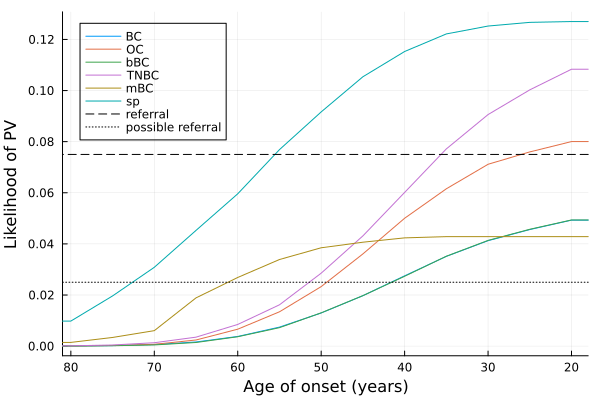

In [8]:
age = collect(81:-1:18)
plot(age, f_bc.(age),
    xflip=true,
    leg=:topleft,
    label="BC",
    xlims=[minimum(age), maximum(age)],
    xlabel="Age of onset (years)",
    ylabel="Likelihood of PV",
    background=:transparent,
    fmt=:tex
)
plot!(age, f_oc.(age), label="OC")
plot!(age, f_bbc.(age), label="bBC")
plot!(age, f_tnbc.(age), label="TNBC")
plot!(age, f_mbc.(age), label="mBC")
plot!(age, f_sp.(age), label="sp")
hline!([0.075], label="referral", linestyle=:dash, linecolor="black")
hline!([0.025], label="possible referral", linestyle=:dot, linecolor="black")

### Mass Assignments

Default case: The proband's age is known exactly.

In [9]:
function m(age::Integer)
    return BPA(
        :BC   => f_bc(age),
        :bBC  => f_bbc(age),
        :TNBC => f_tnbc(age),
        :mBC  => f_mbc(age),
        :OC   => f_oc(age),
        :sp   => f_sp(age),
    )
end

m (generic function with 1 method)

Interval case: If the age of onset (e.g., of a distant relative) is not known exactly, the age parameter can be expressed as an interval.

In [10]:
function m(age::Interval)
    return BPA(
        :BC   => meval(f_bc, age),
        :bBC  => meval(f_bbc, age),
        :TNBC => meval(f_tnbc, age),
        :mBC  => meval(f_mbc, age),
        :OC   => meval(f_oc, age),
        :sp   => meval(f_sp, age),
    )
end

m (generic function with 2 methods)

## GLM

For comparison, we train a logistic regression model on the same source data used to compute the absolute frequencies above.

In [12]:
using GLM

In [13]:
df_train = CSV.read("train.csv", DataFrame);
df_test = CSV.read("test.csv", DataFrame);

In [14]:
formula = @formula(brca ~ fh + bc_age + bc_bil + bc_tn + bc_m + oc_age + sp);
logit_model = glm(formula, df_train, Binomial(), LogitLink())

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

brca ~ 1 + fh + bc_age + bc_bil + bc_tn + bc_m + oc_age + sp

Coefficients:
────────────────────────────────────────────────────────────────────────────────
                   Coef.   Std. Error       z  Pr(>|z|)   Lower 95%    Upper 95%
────────────────────────────────────────────────────────────────────────────────
(Intercept)  -1.14312     0.0219461    -52.09    <1e-99  -1.18614    -1.10011
fh            0.00126723  0.0146032      0.09    0.9308  -0.0273545   0.0298889
bc_age       -0.0414821   0.000431544  -96.12    <1e-99  -0.0423279  -0.0406362
bc_bil       -0.0312222   0.0188856     -1.65    0.0983  -0.0682372   0.00579294
bc_tn         1.05298     0.0168234     62.59    <1e-99   1.02001     1.08596
bc_m          0.49631     0.0900304      5.51    

In [15]:
df_test[:, "prediction"] = predict(logit_model, df_test);

## Examples

#### **Pattern 1:** Father with BC at 42, second degree relative with BC>50

In [16]:
m1 = combine_dempster(m(interval(42)), m(interval(51, 60)))
bel1 = bel([:BC, :mBC], m1)
print_comparison_table(bel1, 0.257, 0.27, 0.06)

This approach,Prev. approach,Penn II,BOADICEA
"[0.078, 0.1]","[0.26, 0.26]","[0.27, 0.27]","[0.06, 0.06]"


#### **Pattern 2:** Patient with BC<40 and mother with BC<50

In [17]:
m2 = combine_dempster(m(interval(20, 40)), m(interval(41, 50)))
bel2 = bel([:BC], m2)
print_comparison_table(bel2, 0.198, "[0.15, 0.35]", 0.0521)

This approach,Prev. approach,Penn II,BOADICEA
"[0.028, 0.065]",0.198,"[0.15, 0.35]",0.0521


#### **Pattern 3:** Patient with OC<40 and her aunt BC<50

In [18]:
m3 = m2
bel3 = bel([:BC, :OC], m3)
print_comparison_table(bel3, 0.358, "[0.12, 0.4]", 0.0319)

This approach,Prev. approach,Penn II,BOADICEA
"[0.079, 0.18]",0.358,"[0.12, 0.4]",0.0319


#### **Pattern 4:** Patient aged 22 with BC and OC; mother has bBC>50

In [19]:
m4 = combine_dempster(m(interval(22)), m(interval(50, 60)))
bel4 = bel([:BC, :OC, :sp, :bBC], m4)
print_comparison_table(bel4, 0.527, 0.54, 0.3208)

This approach,Prev. approach,Penn II,BOADICEA
"[0.3, 0.39]","[0.53, 0.53]","[0.54, 0.54]","[0.32, 0.32]"
